# Double DQN — LunarLander-v2

## 1. Konfiguracja

In [1]:
import torch
import random
import numpy as np
import gym
import warnings

SEED = 42
OPTIMIZE_WITH_HARDWARE = True

device = torch.device('cpu')
if OPTIMIZE_WITH_HARDWARE:
    if torch.backends.mps.is_available():
        device = torch.device('mps')
        print('Wybrano urz\u0105dzenie: MPS')
    elif torch.cuda.is_available():
        device = torch.device('cuda')
        print('Wybrano urz\u0105dzenie: GPU z obs\u0142ug\u0105 CUDA')
        print(f'Nazwa urz\u0105dzenia CUDA: {torch.cuda.get_device_name()}')
else:
    print('Wybrano urz\u0105dzenie: CPU')

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

warnings.filterwarnings("ignore")

Wybrano urządzenie: GPU z obsługą CUDA
Nazwa urządzenia CUDA: Quadro M1200


## 2. Inicjalizacja środowiska

In [2]:
env = gym.make("LunarLander-v2")
env.action_space.seed(SEED)
env.observation_space.seed(SEED)

state = env.reset()
if isinstance(state, tuple):
    state = state[0]

terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    result = env.step(action)
    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
        done = terminated or truncated
    else:
        next_state, reward, done, info = result
    env.render()
    if done:
        break

env.close()

print(f'Ilo\u015b\u0107 mo\u017cliwych akcji: {env.action_space.n}')

Ilość możliwych akcji: 4


## 3. Hiperparametry

In [3]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995
MEMORY_SIZE = 100000
TRAIN_START = 1000
TARGET_UPDATE_STEPS = 1000
MAX_EPISODES = 500
MAX_STEPS = 1000
HIDDEN_SIZES = (128, 128)

## 4. Sieć neuronowa

In [4]:
import torch.nn as nn


class DQNetwork(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=HIDDEN_SIZES):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        layers.append(nn.Linear(prev, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, state):
        return self.net(state)

## 5. Agent DQN

In [5]:
from collections import deque


class DQNAgent:
    def __init__(self, input_size, output_size):
        self.output_size = output_size
        self.epsilon = EPSILON_START
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.total_steps = 0
        self.model = DQNetwork(input_size, output_size).to(device)
        self.target_model = DQNetwork(input_size, output_size).to(device)
        self.update_target_model()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=LEARNING_RATE)
        self.loss_function = nn.SmoothL1Loss()

    def update_target_model(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def memorize(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.output_size)
        state = torch.FloatTensor(state).to(device).unsqueeze(0)
        with torch.no_grad():
            return torch.argmax(self.model(state)).item()

    def replay(self):
        if len(self.memory) < TRAIN_START:
            return
        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(np.array(dones, dtype=np.float32)).unsqueeze(1).to(device)

        q_values = self.model(states).gather(1, actions)
        next_actions = self.model(next_states).argmax(1).unsqueeze(1)
        next_q_values = self.target_model(next_states).gather(1, next_actions).detach()
        target_q_values = rewards + GAMMA * next_q_values * (1 - dones)

        loss = self.loss_function(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        self.optimizer.step()

        self.total_steps += 1
        if self.total_steps % TARGET_UPDATE_STEPS == 0:
            self.update_target_model()

    def decay_epsilon(self):
        self.epsilon = max(EPSILON_MIN, self.epsilon * EPSILON_DECAY)

## 6. Trening

In [6]:
env = gym.make("LunarLander-v2")
env.action_space.seed(SEED)
env.observation_space.seed(SEED)
input_size = env.observation_space.shape[0]
output_size = env.action_space.n
agent = DQNAgent(input_size, output_size)

rewards_history = []

for episode in range(MAX_EPISODES):
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]
    total_reward = 0
    done = False
    step = 0

    while not done and step < MAX_STEPS:
        action = agent.act(state)
        result = env.step(action)
        if len(result) == 5:
            next_state, reward, terminated, truncated, info = result
            done = terminated or truncated
        else:
            next_state, reward, done, info = result

        agent.memorize(state, action, reward, next_state, done)
        total_reward += reward
        state = next_state
        agent.replay()
        step += 1

    agent.decay_epsilon()
    rewards_history.append(total_reward)
    print(f"Epizod {episode + 1}/{MAX_EPISODES}, Nagroda: {total_reward:.2f}, Epsilon: {agent.epsilon:.3f}")

torch.save({
    'model_state_dict': agent.model.state_dict(),
    'optimizer_state_dict': agent.optimizer.state_dict(),
    'epsilon': agent.epsilon,
}, 'dqn_lunar_lander.pth')

env.close()

Epizod 1/500, Nagroda: -425.00, Epsilon: 0.995
Epizod 2/500, Nagroda: -175.19, Epsilon: 0.990
Epizod 3/500, Nagroda: -357.29, Epsilon: 0.985
Epizod 4/500, Nagroda: -465.45, Epsilon: 0.980
Epizod 5/500, Nagroda: -364.85, Epsilon: 0.975
Epizod 6/500, Nagroda: -209.62, Epsilon: 0.970
Epizod 7/500, Nagroda: -440.81, Epsilon: 0.966
Epizod 8/500, Nagroda: -113.37, Epsilon: 0.961
Epizod 9/500, Nagroda: -341.48, Epsilon: 0.956
Epizod 10/500, Nagroda: -541.49, Epsilon: 0.951
Epizod 11/500, Nagroda: -146.34, Epsilon: 0.946
Epizod 12/500, Nagroda: -8.63, Epsilon: 0.942
Epizod 13/500, Nagroda: -293.95, Epsilon: 0.937
Epizod 14/500, Nagroda: -169.95, Epsilon: 0.932
Epizod 15/500, Nagroda: -136.75, Epsilon: 0.928
Epizod 16/500, Nagroda: -102.96, Epsilon: 0.923
Epizod 17/500, Nagroda: -296.74, Epsilon: 0.918
Epizod 18/500, Nagroda: -144.30, Epsilon: 0.914
Epizod 19/500, Nagroda: -87.52, Epsilon: 0.909
Epizod 20/500, Nagroda: -141.08, Epsilon: 0.905
Epizod 21/500, Nagroda: -210.76, Epsilon: 0.900
Epiz

## 7. Wizualizacja wyników

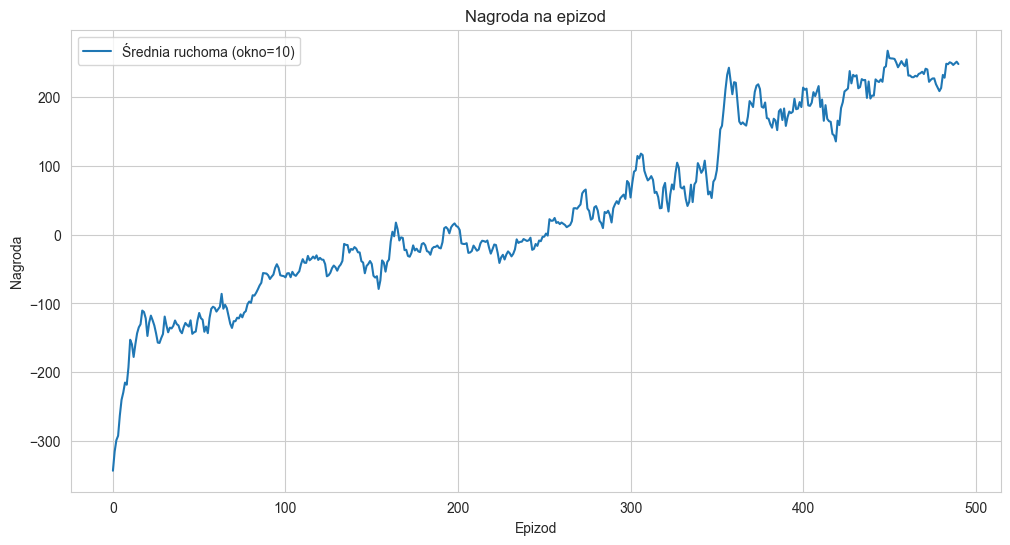

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

window_size = 10
moving_avg = np.convolve(rewards_history, np.ones(window_size) / window_size, mode='valid')

plt.figure(figsize=(12, 6))
plt.plot(moving_avg, label=f"\u015arednia ruchoma (okno={window_size})")
plt.title("Nagroda na epizod")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.legend()
plt.show()